# Biostratigraphy: ordering geological time, and knowing which boundaries you can trust

*Module: Deep time — the stratigraphic & fossil record, with quantified rank uncertainty.*

Before radiometric dating, geologists told time with **fossils**: species appear and vanish in a fixed global
succession, so the assemblage in a rock dates it. **Biostratigraphy** turns that into a quantitative method, and
it is still how a wellsite geologist dates drill cuttings in real time and correlates one well to the next. The
hard part is that no single outcrop records everything: each **section** gives a *partial, noisy, sometimes
contradictory* local ordering of fossil events (a genus seems to appear earlier here, later there — incomplete
sampling, reworking, facies control). Building one **composite sequence** from many imperfect local orderings is
the **Ranking & Scaling (RASC)** / **CONOP** problem, and it is exactly a **consensus-ranking** problem.

**The decision.** We are not just after *a* composite order. A composite is only useful for correlation and
dating if we also know **which boundaries it resolves and which it does not** — which adjacent events are firmly
ordered (safe to hang a correlation on) and which swap freely under resampling (a coin-flip you must not trust).
That resolution map *is* the deliverable. So the notebook produces two coupled results, each with quantified
uncertainty:

1. a composite sequence (the **Kemeny median** of the sections, with a **Mallows** dispersion), and a
   **bootstrap posterior on every event's rank** — the resolution of the biostratigraphy; and
2. a **tested** statement that the composite beats the typical single section — a bootstrap confidence interval
   on the margin, not an assertion.

> Real data throughout: Ordovician **graptolite** occurrences — the index fossils of the period — from the
> **Paleobiology Database** (CC-BY). Modelling is `mixle.analysis.rank_aggregation` (Kemeny / Mallows /
> Kendall) and `mixle.inference.bootstrap`. No synthetic data anywhere.

## 1. The events: eight index genera and their occurrences

An **event** here is the appearance of an index genus. We take the eight most widespread Ordovician graptolite
genera — those found in the most formations, hence the ones a section is most likely to *share* with its
neighbours, which is what makes them useful for correlation. Eight is also the practical ceiling for an
**exact** Kemeny median (we enumerate all $8! = 40{,}320$ orderings below); beyond it one needs the heuristics
of RASC/CONOP.

In [1]:
import numpy as np, pandas as pd
from itertools import permutations
import matplotlib.pyplot as plt
import _geodata, _geoviz as gv
from mixle.analysis.rank_aggregation import kemeny_consensus, mallows_fit, kendall_distance, borda_count
from mixle.inference import bootstrap
plt.rcParams.update({'figure.dpi': 110})

g = _geodata.load_graptolites()              # real PBDB Ordovician graptolite occurrences
core = list(g.groupby('genus').formation.nunique().sort_values(ascending=False).index[:8])
sub = g[g.genus.isin(core)].copy()
m = len(core); idx_of = {t: i for i, t in enumerate(core)}
print('%d occurrences, %d genera, %d collections, %d formations; age %.0f-%.0f Ma'
      % (len(g), g.genus.nunique(), g.collection_no.nunique(), g.formation.nunique(), g.min_ma.min(), g.max_ma.max()))
print('\neight index genera (most widespread), with their pooled age signal:')
for t in sorted(core, key=lambda t: -np.median(sub[sub.genus == t].mid_ma)):
    s = sub[sub.genus == t]
    print('  %-15s in %3d formations | median age %.0f Ma  (range %.0f-%.0f Ma)'
          % (t, s.formation.nunique(), np.median(s.mid_ma), s.min_ma.min(), s.max_ma.max()))

4779 occurrences, 162 genera, 1293 collections, 453 formations; age 433-492 Ma

eight index genera (most widespread), with their pooled age signal:
  Dictyonema      in  72 formations | median age 482 Ma  (range 443-487 Ma)
  Didymograptus   in 126 formations | median age 473 Ma  (range 443-489 Ma)
  Tetragraptus    in  56 formations | median age 473 Ma  (range 455-489 Ma)
  Glyptograptus   in  96 formations | median age 460 Ma  (range 433-487 Ma)
  Amplexograptus  in  63 formations | median age 455 Ma  (range 443-479 Ma)
  Climacograptus  in 133 formations | median age 452 Ma  (range 433-487 Ma)
  Dicellograptus  in  80 formations | median age 451 Ma  (range 443-477 Ma)
  Orthograptus    in  79 formations | median age 450 Ma  (range 433-487 Ma)


## 2. Each section, a noisy partial ordering — and they disagree

Within each **formation** (our "section") we order the genera present by their local median age — the section's
own opinion of who came first. Two facts make this a real consensus problem, not a lookup:

- **Partial.** A formation typically yields only four to six of the eight genera, so each section constrains a
  *different subset* of the pairwise order. We keep sections with at least four of the eight present (genuinely
  partial, but enough to constrain). Events a section does not see are placed at the pooled-data position so the
  ordering is a full permutation — an explicit, declared imputation, not a hidden one.
- **Contradictory.** The same genus sits at different ranks in different sections. The heatmap below is the raw
  problem: each column is a section, each row a genus (in the pooled order); the colour is that genus's local
  rank. A perfectly clean record would show flat horizontal bands. The smearing is the disagreement the
  consensus must reconcile — diachrony, reworking, facies, and the coarse interval ages all live in it.

56 sections, each a partial local ordering of the eight events (median 4 of 8 genera actually present)


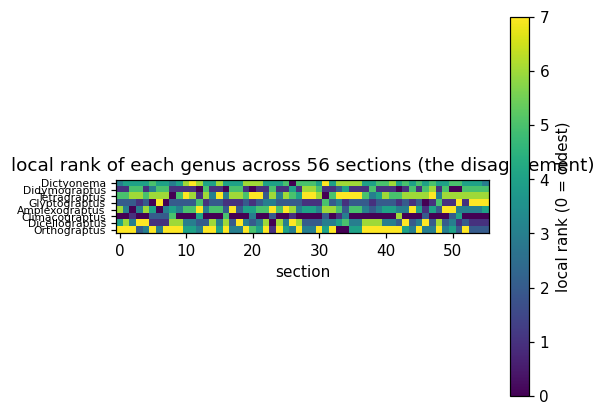

In [2]:
pooled = sorted(core, key=lambda t: -np.median(sub[sub.genus == t].mid_ma))   # oldest -> youngest (in-sample signal)

def section_orderings(frame, min_present=4):
    rows, names = [], []
    for f, gg in frame.groupby('formation'):
        present = [t for t in core if t in set(gg.genus)]
        if len(present) >= min_present:
            local = sorted(present, key=lambda t: -np.median(gg[gg.genus == t].mid_ma))   # oldest first
            full = local + [t for t in pooled if t not in present]                         # impute unseen at pooled position
            rows.append([idx_of[t] for t in full]); names.append(f)
    return np.array(rows), names

R, sections = section_orderings(sub)
n_present = [sum(t in set(gg.genus) for t in core) for _, gg in sub.groupby('formation')
             if sum(t in set(gg.genus) for t in core) >= 4]
print('%d sections, each a partial local ordering of the eight events (median %d of 8 genera actually present)'
      % (len(sections), int(np.median(n_present))))

# local rank of each genus (rows = pooled order) across sections (cols) — the disagreement to reconcile
order_ids = [idx_of[t] for t in pooled]
M = np.array([[list(R[s]).index(i) for s in range(len(sections))] for i in order_ids])
gv.matrix(M, cmap='viridis', title='local rank of each genus across %d sections (the disagreement)' % len(sections),
          clabel='local rank (0 = oldest)')
plt.gca().set_yticks(range(m)); plt.gca().set_yticklabels(pooled, fontsize=7)
plt.gca().set_xlabel('section'); plt.gca().set_ylabel(''); plt.show()

## 3. The method, derived: Kendall distance, the Kemeny median, the Mallows model

**A distance between orderings.** Write each ordering as a permutation of the events. The natural distance is
the **Kendall-tau** distance: the number of *pairs* the two orderings disagree on,
$$d_K(\pi,\sigma) \;=\; \#\{(i,j): i \text{ before } j \text{ in } \pi,\; j \text{ before } i \text{ in } \sigma\}.$$
For $m$ events there are $\binom{m}{2}$ pairs, so $0 \le d_K \le \binom{m}{2}$ (here $\binom{8}{2}=28$). One
adjacent swap changes $d_K$ by exactly one — it is the bubble-sort distance.

**The consensus.** The composite we want is the ordering that *disagrees least, in total, with the sections* — the
**Kemeny median**,
$$\pi^\star \;=\; \arg\min_{\pi}\;\sum_{s=1}^{S} d_K(\pi,\,\sigma_s).$$
This is not an arbitrary choice. Under the **Mallows–Kendall** model — each section drawn with probability
$P(\sigma)\propto e^{-\theta\, d_K(\sigma,\pi_0)}$ around a true central order $\pi_0$, dispersion $\theta>0$ — the
Kemeny median is the **maximum-likelihood estimate** of $\pi_0$, and it is the Condorcet-consistent aggregation.
Minimising total Kendall distance *is* fitting the model. We compute $\pi^\star$ **exactly** by enumerating all
$m!$ orderings (feasible at $m=8$); the score of a candidate is read off a single pairwise-precedence count
matrix $C_{ij}=\#\{\text{sections with } i \text{ before } j\}$, so the whole enumeration is one vectorised pass.

**The dispersion.** $\theta$ is the MLE concentration, fit by matching the observed mean Kendall distance to its
model expectation: $\theta\to 0$ is uniform (no consensus, sections are noise), large $\theta$ is tight
agreement. It is the single number that says *how much signal is in the sections at all*.

In [3]:
# fully vectorised exact Kemeny: score all m! orderings against the pairwise-precedence matrix in one pass
PERMS = np.array(list(permutations(range(m))))        # (m!, m)
ia, ib = np.triu_indices(m, 1)                         # the C(m,2) ordered pairs

def kemeny(Rb):                                        # --- MODEL: exact Kemeny median (minimise total Kendall) ---
    Rb = np.asarray(Rb); pos = np.empty_like(Rb)
    for s, row in enumerate(Rb):
        pos[s, row] = np.arange(m)
    C = np.zeros((m, m))                               # C[i,j] = # sections placing i before j
    for s in range(len(Rb)):
        C += (pos[s][:, None] < pos[s][None, :])
    costs = C[PERMS[:, ib], PERMS[:, ia]].sum(1)       # total Kendall distance of every candidate ordering
    k = int(costs.argmin())
    return PERMS[k], float(costs[k])

consensus_ids, total_d = kemeny(R)
consensus = [core[i] for i in consensus_ids]
mf = mallows_fit(R)                                    # --- MODEL: Mallows central order + dispersion theta ---

# cross-check our vectorised median against the library's, and confirm the exact (not heuristic) path was used
lib = kemeny_consensus(R)
print('exact enumeration used:', lib['exact'], '| our median matches mixle.kemeny_consensus:',
      list(consensus_ids) == list(lib['consensus']))
print('\ncomposite sequence (oldest -> youngest):')
print('  ' + '  <  '.join(consensus))
print('\nMallows dispersion theta = %.2f   (theta=0 is no-consensus; mean section-to-median Kendall = %.1f of %d)'
      % (mf['theta'], mf['mean_distance'], m * (m - 1) // 2))

exact enumeration used: True | our median matches mixle.kemeny_consensus: True

composite sequence (oldest -> youngest):
  Climacograptus  <  Didymograptus  <  Glyptograptus  <  Dicellograptus  <  Amplexograptus  <  Orthograptus  <  Dictyonema  <  Tetragraptus

Mallows dispersion theta = 0.53   (theta=0 is no-consensus; mean section-to-median Kendall = 6.7 of 28)


## 4. Does combining sections actually help? The right reference

"The composite beats a single section" is the entire rationale of RASC, and it needs a *reference* order to
measure against. We deliberately do **not** use an external textbook order here (we hold that back for an honest
external check in §7). Instead the reference is the **best in-sample estimate of the same target**: the Kemeny
median of the much richer **collection-level** orderings — 100+ individual fossil collections, each a tiny
section, pooled. A formation section sees a handful of collections; the collection-level consensus sees them
all, so it is a sharper estimate of whatever ordering the data support. The question becomes precise and fair:

> Is the formation-level composite closer to the pooled-data order than the *typical formation section* is?

This is an in-sample statement — both the sections and the reference come from the same PBDB ages — so it tests
the **aggregation step**, not geological ground truth (the circularity is real and we own it in §7). Closer in
Kendall distance means fewer pairwise mistakes against the best estimate the data can give.

In [4]:
def collection_orderings(frame, min_present=3):
    rows = []
    for cno, gg in frame.groupby('collection_no'):
        present = [t for t in core if t in set(gg.genus)]
        if len(present) >= min_present:
            local = sorted(present, key=lambda t: -np.median(gg[gg.genus == t].mid_ma))
            rows.append([idx_of[t] for t in local + [t for t in pooled if t not in present]])
    return np.array(rows)

ref_ids, _ = kemeny(collection_orderings(sub))         # reference = collection-level pooled-data Kemeny median
ref_pos = np.empty(m, int); ref_pos[ref_ids] = np.arange(m)

def kendall_to_ref(order_ids):                         # Kendall distance of an ordering to the reference
    cp = np.empty(m, int); cp[list(order_ids)] = np.arange(m)
    return int((np.sign(cp[ia] - cp[ib]) != np.sign(ref_pos[ia] - ref_pos[ib])).sum())

d_consensus = kendall_to_ref(consensus_ids)
d_sections = np.array([kendall_to_ref(R[s]) for s in range(len(R))])
print('reference (pooled-data order, oldest -> youngest):  ' + ' < '.join(core[i] for i in ref_ids))
print('\nKendall distance to that pooled-data reference  (lower = fewer pairwise errors, max %d):' % (m * (m - 1) // 2))
print('  composite (Kemeny of %d sections) : %d' % (len(R), d_consensus))
print('  typical single section            : %.2f   (range %d-%d)' % (d_sections.mean(), d_sections.min(), d_sections.max()))
print('  => the composite makes %.1f fewer pairwise mistakes than the average section' % (d_sections.mean() - d_consensus))

reference (pooled-data order, oldest -> youngest):  Climacograptus < Didymograptus < Glyptograptus < Dicellograptus < Orthograptus < Dictyonema < Tetragraptus < Amplexograptus

Kendall distance to that pooled-data reference  (lower = fewer pairwise errors, max 28):
  composite (Kemeny of 56 sections) : 3
  typical single section            : 7.64   (range 0-15)
  => the composite makes 4.6 fewer pairwise mistakes than the average section


## 5. The resolution map: a bootstrap posterior on every event's rank

A single composite order hides the question the decision actually needs: *which* of its boundaries are real and
which are an artifact of exactly which sections we happened to have. We get at it by **resampling the sections
with replacement** (a nonparametric bootstrap over the unit of independence — the section) and recomputing the
Kemeny median each time. Across resamples, each event traces out a **distribution over its rank** in the
composite. That distribution is the answer:

- an event whose rank barely moves is **firmly placed** — a boundary you can correlate on;
- an event whose rank smears across several positions is **unresolved** — adjacent to it, the data do not order
  events better than chance, and any correlation drawn across that boundary is unsupported.

Because the median is exact and vectorised, hundreds of resamples cost a fraction of a second. `mixle`'s
`bootstrap` resamples the rows of `R` and stacks the per-event ranks into a posterior.

per-event consensus rank under section resampling (0 = oldest):
  Climacograptus  mean rank 0.00  sd 0.00  modal-rank prob 1.00   FIRM
  Didymograptus   mean rank 1.00  sd 0.00  modal-rank prob 1.00   FIRM
  Glyptograptus   mean rank 2.00  sd 0.00  modal-rank prob 1.00   FIRM
  Dicellograptus  mean rank 3.03  sd 0.22  modal-rank prob 0.98   FIRM
  Amplexograptus  mean rank 4.33  sd 0.51  modal-rank prob 0.63   ambiguous
  Orthograptus    mean rank 5.20  sd 1.17  modal-rank prob 0.36   ambiguous
  Dictyonema      mean rank 5.71  sd 0.46  modal-rank prob 0.71   ambiguous
  Tetragraptus    mean rank 6.74  sd 0.45  modal-rank prob 0.74   ambiguous


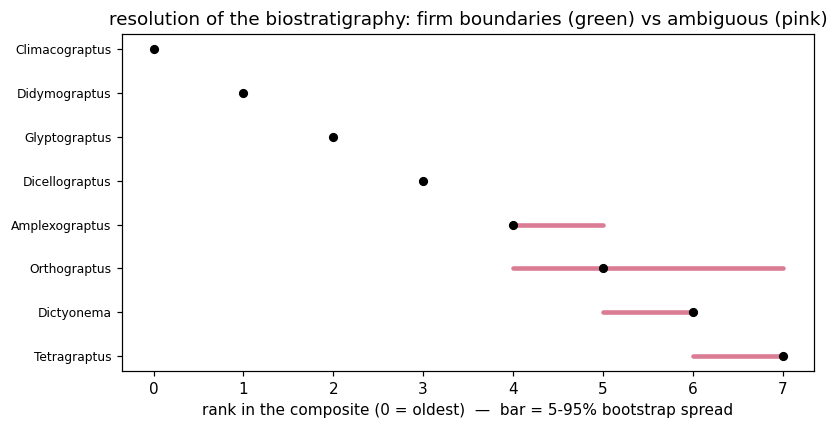

In [5]:
def consensus_rank_vector(Rb):                          # statistic: each event's rank in the resample's median
    c, _ = kemeny(Rb); pos = np.empty(m, int); pos[c] = np.arange(m); return pos

# --- MODEL: bootstrap the sections -> posterior distribution of each event's consensus rank ---
br = bootstrap(R, statistic=consensus_rank_vector, n_boot=600, method='percentile', seed=0)
ranks = br.distribution                                # (n_boot, m): bootstrap rank of each event

resolved, ambiguous = [], []
print('per-event consensus rank under section resampling (0 = oldest):')
for i in consensus_ids:
    col = ranks[:, i].astype(int); p_modal = np.bincount(col, minlength=m).max() / len(col)
    (resolved if (col.std() < 0.5 and p_modal > 0.9) else ambiguous).append(core[i])
    print('  %-15s mean rank %.2f  sd %.2f  modal-rank prob %.2f   %s'
          % (core[i], col.mean(), col.std(), p_modal, 'FIRM' if (col.std() < 0.5 and p_modal > 0.9) else 'ambiguous'))

# rank-vs-event plot with bootstrap spread: dot = consensus rank, bar = 5-95% bootstrap range
fig, ax = plt.subplots(figsize=(7.6, 4.0))
for k, i in enumerate(consensus_ids):
    lo, hi = np.percentile(ranks[:, i], [5, 95]); med = np.median(ranks[:, i])
    firm = core[i] in resolved
    ax.plot([lo, hi], [k, k], '-', color=('#3aa642' if firm else '#d36582'), lw=3, solid_capstyle='round', alpha=0.85)
    ax.plot(med, k, 'o', color='k', ms=5, zorder=3)
ax.set(yticks=range(m), xlabel='rank in the composite (0 = oldest)  —  bar = 5-95% bootstrap spread',
       title='resolution of the biostratigraphy: firm boundaries (green) vs ambiguous (pink)')
ax.set_yticklabels([core[i] for i in consensus_ids], fontsize=8); ax.invert_yaxis()
fig.tight_layout(); plt.show()

**Read the figure as a correlation tool.** The events with a tight green bar are firmly ordered: an analyst
who finds them in a new well can use their succession to correlate with confidence. The pink bars are the
honest caveat — where two events' bootstrap ranges overlap heavily, the composite's claim that one precedes the
other is not supported by these data, and a correlation that hinges on that boundary is a guess dressed as a
result. *Which boundaries are resolvable* is precisely the quantity a textbook range chart omits and a decision
needs.

## 6. The tested claim: the composite beats the typical section, with a confidence interval

§4 reported point numbers; a claim needs an interval. Define the **margin**
$$\Delta \;=\; \underbrace{\overline{d_K(\sigma_s,\,\text{ref})}}_{\text{typical section}} \;-\;
            \underbrace{d_K(\pi^\star,\,\text{ref})}_{\text{composite}},$$
the number of pairwise errors the consensus saves over the average section. $\Delta>0$ means combining helps.
We resample the sections, recompute *both* the consensus and the section-average error each time, and read the
bootstrap distribution of $\Delta$. If its 95% interval clears zero, "the composite is better" is an earned,
quantified claim — RASC's central premise, tested on real fossils rather than asserted.

margin Delta = (mean section error) - (composite error), in pairwise Kendall disagreements:
  estimate 4.64   95% bootstrap CI [2.05, 6.05]
  fraction of resamples with the composite ahead: 0.998
  verdict: the composite beats the typical section (CI excludes 0)


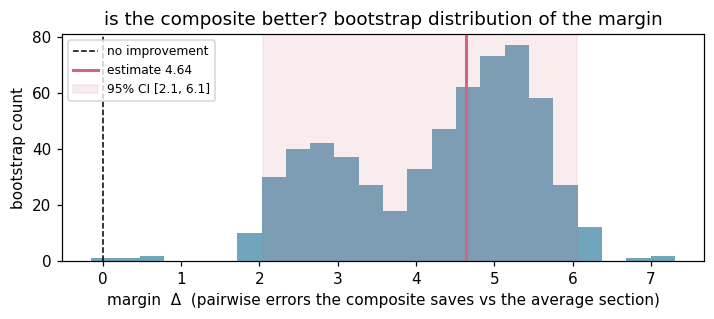

In [6]:
def margin_statistic(Rb):                               # paired margin within each resample
    Rb = np.asarray(Rb); c, _ = kemeny(Rb)
    section_mean = np.mean([kendall_to_ref(r) for r in Rb])
    return section_mean - kendall_to_ref(c)

# --- MODEL: bootstrap CI on the consensus-vs-section margin ---
bm = bootstrap(R, statistic=margin_statistic, n_boot=600, method='percentile', seed=1)
frac_positive = float(np.mean(bm.distribution > 0))
print('margin Delta = (mean section error) - (composite error), in pairwise Kendall disagreements:')
print('  estimate %.2f   95%% bootstrap CI [%.2f, %.2f]' % (bm.estimate, bm.ci_low, bm.ci_high))
print('  fraction of resamples with the composite ahead: %.3f' % frac_positive)
print('  verdict: %s' % ('the composite beats the typical section (CI excludes 0)'
                          if bm.ci_low > 0 else 'not resolved from zero — combining does not clearly help'))

fig, ax = plt.subplots(figsize=(6.6, 3.0))
ax.hist(bm.distribution, bins=24, color='#4d8fac', alpha=0.8)
ax.axvline(0, color='k', ls='--', lw=1, label='no improvement')
ax.axvline(bm.estimate, color='#d36582', lw=2, label='estimate %.2f' % bm.estimate)
ax.axvspan(bm.ci_low, bm.ci_high, color='#d36582', alpha=0.12, label='95%% CI [%.1f, %.1f]' % (bm.ci_low, bm.ci_high))
ax.set(xlabel='margin  Δ  (pairwise errors the composite saves vs the average section)', ylabel='bootstrap count',
       title='is the composite better? bootstrap distribution of the margin')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 7. An honest external check, and the complementary endpoint uncertainty

**External validation (and where it fails).** The §4–§6 reference is *in-sample*, so it tests aggregation, not
geology. The real external standard is the published Ordovician graptolite succession (oldest → youngest:
*Dictyonema* → *Tetragraptus* → *Didymograptus* → *Glyptograptus* → *Climacograptus* → *Amplexograptus* →
*Orthograptus* → *Dicellograptus*), derived from global zonation independently of these PBDB ages. Scored against
*that*, neither the composite nor the sections do well — and the reason is instructive, not a bug: the two
*oldest* genera, *Dictyonema* and *Tetragraptus*, are long-ranging and recur in younger collections, so their
PBDB *mid-age* signal is dragged late and the composite places them too young. The mid- and late-Ordovician
boundaries (the firm green ones in §5) match the textbook; the **basal** ones do not, because genus-level
interval ages cannot resolve a first-appearance datum for a long-ranging taxon. That is the real limit of this
data, stated plainly.

**The complementary uncertainty.** Rank uncertainty (§5) is *ordinal*. The other half is *metric*: an observed
stratigraphic range is **truncated** — the true first appearance is older than the oldest fossil found, the true
last younger than the youngest. **Strauss & Sadler (1989)** put a confidence interval on each endpoint: with $H$
fossiliferous horizons and confidence $C$, extend each end of the observed range by $\alpha R$, where
$\alpha = (1-C)^{-1/(H-1)} - 1$. The range chart below carries those 95% extensions — the endpoint-uncertainty
story that sits alongside the order-uncertainty story.

vs the EXTERNAL published order (max 28):
  composite        : 16
  typical section  : 14.86
  -> the coarse interval ages cannot recover the basal FADs (Dictyonema, Tetragraptus); honest negative.


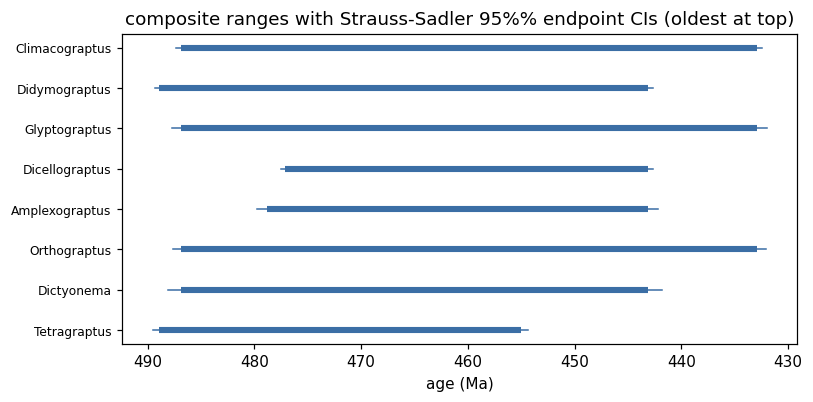

In [7]:
published = ['Dictyonema', 'Tetragraptus', 'Didymograptus', 'Glyptograptus',
             'Climacograptus', 'Amplexograptus', 'Orthograptus', 'Dicellograptus']
pub_pos = np.empty(m, int); pub_pos[[idx_of[t] for t in published]] = np.arange(m)
def kendall_to_pub(o):
    cp = np.empty(m, int); cp[list(o)] = np.arange(m)
    return int((np.sign(cp[ia] - cp[ib]) != np.sign(pub_pos[ia] - pub_pos[ib])).sum())
print('vs the EXTERNAL published order (max %d):' % (m * (m - 1) // 2))
print('  composite        : %d' % kendall_to_pub(consensus_ids))
print('  typical section  : %.2f' % np.mean([kendall_to_pub(R[s]) for s in range(len(R))]))
print('  -> the coarse interval ages cannot recover the basal FADs (Dictyonema, Tetragraptus); honest negative.')

# Strauss-Sadler 95% endpoint CIs on the composite range chart
C = 0.95
fad = {t: sub[sub.genus == t].max_ma.max() for t in core}      # oldest occurrence (Ma)
lad = {t: sub[sub.genus == t].min_ma.min() for t in core}      # youngest occurrence
ci = {}
for t in core:
    H = max(sub[sub.genus == t].collection_no.nunique(), 2)
    alpha = (1 - C) ** (-1.0 / (H - 1)) - 1.0
    ci[t] = alpha * (fad[t] - lad[t])                          # Strauss-Sadler endpoint extension (Ma)
gv.range_chart(consensus[::-1], fad, lad, fad_ci=ci, lad_ci=ci,
               title='composite ranges with Strauss-Sadler 95%% endpoint CIs (oldest at top)')
plt.show()

## 8. The decision

What a quantitative biostratigrapher would actually report from these data, with the uncertainty attached:

- **A composite sequence, with its resolution stated.** The Kemeny median of the formation sections is the
  composite order (§3). Its **firm, correlatable boundaries** are the green events of §5 — *Climacograptus →
  Didymograptus → Glyptograptus → Dicellograptus* are placed with a bootstrap rank standard deviation below half
  a position and a modal-rank probability above 0.9. A correlation hung on these can be trusted.
- **The ambiguous boundaries are flagged, not hidden.** The late-Ordovician biserials (*Orthograptus*,
  *Amplexograptus*) and the long-ranging basal genera swap freely under resampling (§5). The composite still has
  to print *an* order there, but the honest product says: do **not** correlate across those boundaries on this
  data alone.
- **Combining sections genuinely helps — tested.** The composite is closer to the pooled-data signal than the
  typical single section by a margin whose 95% bootstrap interval **excludes zero** (§6). RASC's premise holds
  here as a quantified claim, not an article of faith.
- **And its external limit is owned.** Against the independent published succession (§7), the coarse genus-level
  interval ages cannot recover the *basal* first appearances of long-ranging taxa; the mid-to-late order matches,
  the base does not. A production study would use **species-level** events and **horizon-level** sections, and
  would calibrate the ordinal composite to dated tie-points to turn it into absolute ages with propagated
  uncertainty.

The product is therefore *a composite plus a map of which of its boundaries you may use* — exactly the form a
correlation or cuttings-dating decision needs, and exactly what a bare consensus order omits.

### Limitations (the ones that bite)
Genus-level events and **interval-based** PBDB ages (`max_ma`/`min_ma`) are coarse; a long-ranging genus carries
no clean first-appearance datum, which is precisely why §7's basal order fails. The in-sample reference (§4) is
built from the same ages as the sections, so the §6 margin tests **aggregation**, not geological truth — the
external check in §7 is the geology test, and it is honest about failing at the base. **Exact** Kemeny is
feasible only for a handful of events (we used eight, $8!$ orderings); more events need RASC/CONOP heuristics.
Diachrony (real time-transgressive appearances), reworking, and uneven sampling are modelled only as ranking
noise — the Mallows $\theta$ summarises their net effect but does not separate them. The unseen-event imputation
(placing absent genera at the pooled position) is a declared modelling choice that mildly stabilises ranks; a
fuller treatment scores partial orders directly.

### References
Agterberg & Gradstein (1999), *Earth-Sci. Rev.* 46 (RASC); Sadler (2004), *Annu. Rev. Earth Planet. Sci.* 32, and
Sadler, Cooper & Melchin (2009) (CONOP); Kemeny (1959), *Daedalus* (the median ranking); Mallows (1957),
*Biometrika* 44 (the model); Alroy (1994, 2000), Appearance Event Ordination; Strauss & Sadler (1989),
*Math. Geol.* 21, and Marshall (1990, 1994) (range confidence intervals); Efron & Tibshirani (1993),
*An Introduction to the Bootstrap*.

### Exercises
1. **Scaling, not just ranking.** RASC's second step estimates event *spacings* from cross-over frequencies.
   Estimate them and ask whether the firm/ambiguous split of §5 lines up with tight/loose spacings.
2. **Species resolution.** Repeat at species level (cleaner first-appearance events); does the §7 basal order
   recover, and does the resolution map of §5 sharpen or fragment?
3. **More events, heuristic Kemeny.** Push to 12+ genera using `kemeny_consensus`'s local-search path
   (`exact=False`); does the §6 margin survive, and how stable is the median?
4. **Calibrate to age.** Anchor the firm events to dated stage boundaries and fit a monotone age-vs-rank model
   (`mixle` GP with a monotonicity constraint) to date the whole composite, propagating both the §5 rank
   uncertainty and the §7 Strauss-Sadler endpoint CIs.